# Project 1: Hatespeech

In [3]:
%pip install pandas seaborn matplotlib wordcloud scikit-learn spacy click

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("project1_train.csv")

## Phase 1: Dataset

### Task 1: Data exploration and pre-processing

**Data Exploration**

It is not about basic statistics. More importantly, it’s essential to
understand the data, especially from the task point of view. The exploration should at
least answer the following questions: 
- Is the dataset balanced or imbalanced? 
- Is the text varied in length, and how does longer text correlate with certain labels? 
- What are the top-k words (or phrases) in hate speech vs non-hate speech? 
- A related important aspect is the context. “Hate” might be a top distinguishing word for hate speech. But “I hate this weather” is not hate speech. 

On top of these, you are encouraged to explore more.

1) Is the dataset balanced?

In [5]:
df['label_name'] = df['label'].map({
    0: 'Non-Hate Speech',
    1: 'Hate Speech'
})

print(df['label_name'].value_counts())

label_name
Hate Speech        816
Non-Hate Speech    798
Name: count, dtype: int64


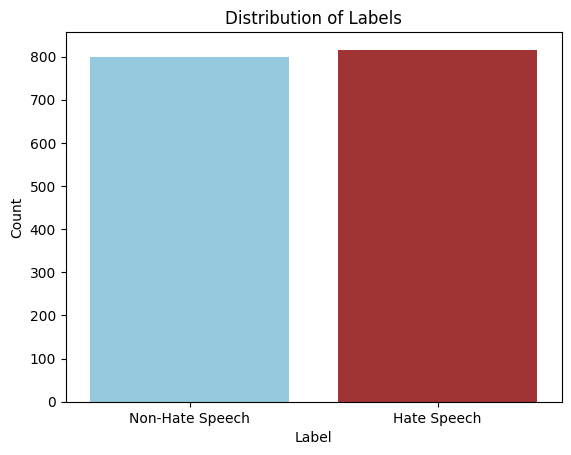

In [6]:
ax = sns.countplot(
    x='label_name',
    hue='label_name',
    data=df,
    palette=['skyblue', 'firebrick'],
    legend=False
)

plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

2) Is the text varied in length, and how does longer text correlate with certain labels? 

In [ ]:
df['comment_length'] = df['text'].apply(len)



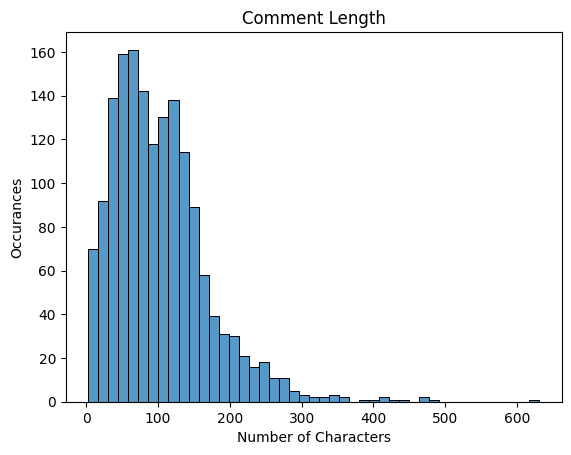

In [ ]:
ax = sns.histplot(df['comment_length'])

plt.title('Comment Length')
plt.xlabel('Number of Characters')
plt.ylabel('Occurances')
plt.show()


In [10]:
df.groupby('label_name')['comment_length'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
label_name,,,,
Hate Speech,119.367647,112.0,64.178143,816
Non-Hate Speech,85.411028,66.0,67.940830,798


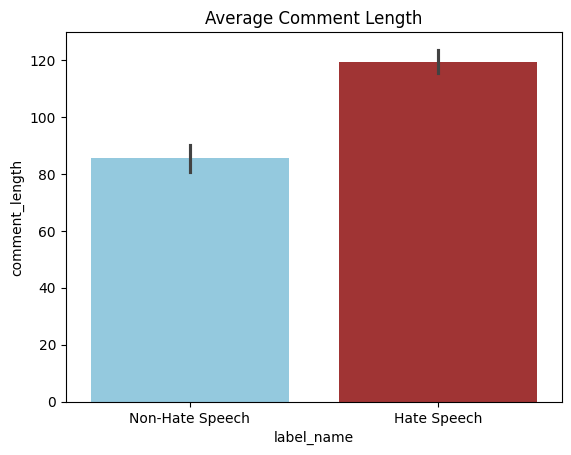

In [11]:
sns.barplot(
    data=df, 
    x='label_name', 
    y='comment_length',
    hue='label_name',
    palette=['skyblue', 'firebrick']
    )

plt.title('Average Comment Length')
plt.show()

3) What are the top-k words (or phrases) in hate speech vs non-hate speech? 

*This section includes a lot of the preprocessing we'll need later*

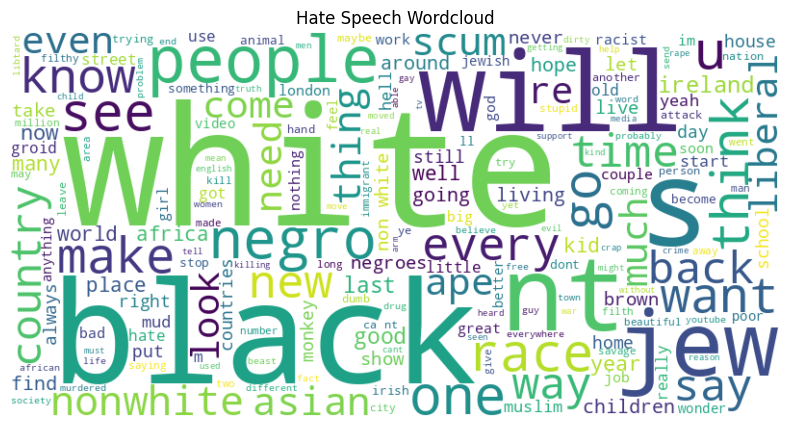

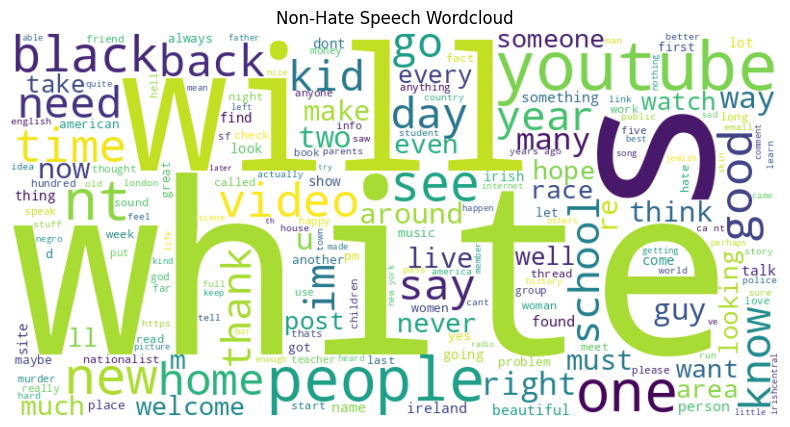

In [12]:
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

###############
# I cleaned the text below in the generate_wordcloud function, but I wanted a full new column in the df as well.
def clean_text(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

#  Creating new column 'clean_text' with the above rules
df['clean_text'] = df['text'].apply(clean_text)
##############

# function to generate word clouds
def generate_wordcloud(text_series, title):
    text = ' '.join(text_series.astype(str).tolist())

    # clean
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = text.lower()

    # remove stopwords
    stopwords = set(STOPWORDS)
    text = ' '.join(word for word in text.split() if word not in stopwords)

    # generate wordcloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    # plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generating the separate df's
hate_df = df[df['label_name'] == 'Hate Speech']
nonhate_df = df[df['label_name'] == 'Non-Hate Speech']

generate_wordcloud(hate_df['text'], "Hate Speech Wordcloud")

generate_wordcloud(nonhate_df['text'], "Non-Hate Speech Wordcloud")

Wordclouds are pretty and fun, but we also need to know what words are most distinctive for each label/class.

Below we'll use TD-IDF (Term Frequency - Inverse Document Frequency) to compare each class's most distinctive words.

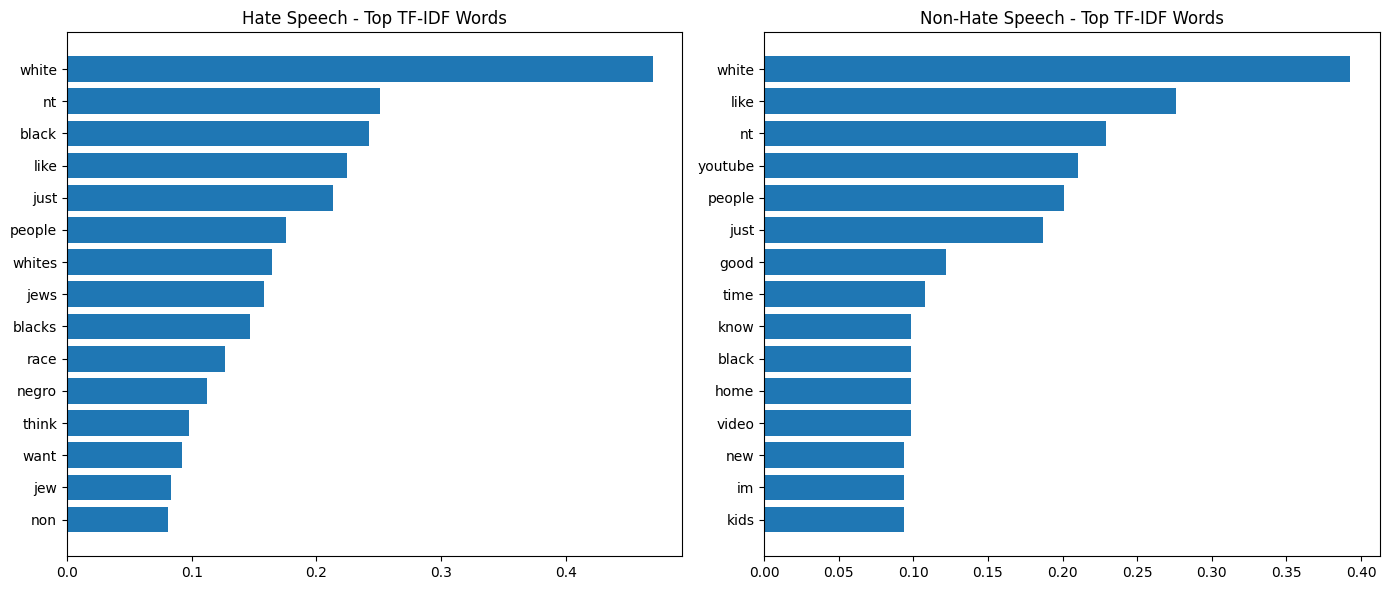

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Preparing text
hate_text = ' '.join(hate_df['clean_text'].astype(str))
nonhate_text = ' '.join(nonhate_df['clean_text'].astype(str))

corpus = [hate_text, nonhate_text]

labels = ['Hate Speech', 'Non-Hate Speech']

# TF-IDF Vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

tfidf = vectorizer.fit_transform(corpus)

feature_names = vectorizer.get_feature_names_out()

#top words per class (change n for more or less words)
def get_top_words(row, n=15):
    row_data = row.toarray().flatten()
    top_indices = row_data.argsort()[-n:][::-1]
    return [(feature_names[i], row_data[i]) for i in top_indices]

hate_top = get_top_words(tfidf[0])
nonhate_top = get_top_words(tfidf[1])

# function to plot
def plot_tfidf(words, title, ax):
    words, scores = zip(*words)
    ax.barh(words[::-1], scores[::-1])
    ax.set_title(title)

#side by side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_tfidf(hate_top, "Hate Speech - Top TF-IDF Words", axes[0])
plot_tfidf(nonhate_top, "Non-Hate Speech - Top TF-IDF Words", axes[1])

plt.tight_layout()
plt.show()

At a Glance:
- Interestingly, we see 'white' used in both as their highest scoring TD_IDF words 

### Lemmatizing

In [14]:
!python -m spacy download en_core_web_sm
import spacy

nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 20.4 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [15]:
def lemmatize_text(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

df['clean_text'] = df['clean_text'].apply(lemmatize_text)

## Models

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

x = df["clean_text"]
y = df["label"]

# converting to numbers
vectorizer = TfidfVectorizer()

x_vec = vectorizer.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_vec, y, test_size=0.2, random_state=89
)

# Best Lambda for Regression Model
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

best_lambda = None
best_accuracy = 0
best_model = None

print("Best λ - Regression Results")
print("---------------------------")

for lam in lambdas:

    C = 1 / lam

    model = LogisticRegression(C=C, max_iter=1000)

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"λ = {lam:<7} Accuracy = {accuracy:.4f}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_lambda = lam
        best_model = model

print("\nBest λ:", best_lambda)
print("Best Accuracy:", round(best_accuracy, 4))

model_1 = LogisticRegression(C=best_lambda)
model_1.fit(x_train, y_train)

# Predictions
y_pred_1 = model_1.predict(x_test)

#Evaluations
accuracy_1 = accuracy_score(y_test, y_pred_1)
precision_1 = precision_score(y_test, y_pred_1)
recall_1 = recall_score(y_test, y_pred_1)
f1_1 = f1_score(y_test, y_pred_1)

print("\nRegression Model Evaluations")
print("----------------------------")
print(f"Accuracy: {accuracy_1: .2f}")
print(f"Precision: {precision_1: .2f}")
print(f"Recall: {recall_1: .2f}")
print(f"F1 Score: {f1_1: .2f}")


from sklearn.naive_bayes import MultinomialNB

# Naive Bayes Model
model_2 = MultinomialNB()
model_2.fit(x_train, y_train)

# Predictions
y_pred_2 = model_2.predict(x_test)

#Evaluations
accuracy_2 = accuracy_score(y_test, y_pred_2)
precision_2 = precision_score(y_test, y_pred_2)
recall_2 = recall_score(y_test, y_pred_2)
f1_2 = f1_score(y_test, y_pred_2)

print("\n")
print("Naive Bayes Model Evaluations")
print("-----------------------------")
print(f"Accuracy: {accuracy_2: .2f}")
print(f"Precision: {precision_2: .2f}")
print(f"Recall: {recall_2: .2f}")
print(f"F1 Score: {f1_2: .2f}")



Best λ - Regression Results
---------------------------
λ = 0.0001  Accuracy = 0.7399
λ = 0.001   Accuracy = 0.7523
λ = 0.01    Accuracy = 0.7461
λ = 0.1     Accuracy = 0.7430
λ = 1       Accuracy = 0.7554
λ = 10      Accuracy = 0.7276

Best λ: 1
Best Accuracy: 0.7554

Regression Model Evaluations
----------------------------
Accuracy:  0.76
Precision:  0.74
Recall:  0.76
F1 Score:  0.75


Naive Bayes Model Evaluations
-----------------------------
Accuracy:  0.71
Precision:  0.64
Recall:  0.92
F1 Score:  0.76
